
# CREDIT CARD FRAUD DETECTION PROJECT
# Dataset: creditcard.csv


#### 1. IMPORT LIBRARIES


In [8]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    precision_recall_curve,
    auc
)


#### 2. LOAD DATASET


In [9]:
df = pd.read_csv("creditcard.csv")

print("Dataset Shape:",df.shape)


print("\nFirst 5 Rows:")
print(df.head())


Dataset Shape: (284807, 31)

First 5 Rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.


#### 3. BASIC DATA INSPECTION



In [10]:
print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())




Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64


#### 4. TARGET VARIABLE ANALYSIS


In [11]:
print("\nClass Distribution:")
print(df["Class"].value_counts())

fraud_percentage = (
    df["Class"].sum() /
    len(df)
) * 100

print(f"\nFraud Percentage: {fraud_percentage:.4f}%")



Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud Percentage: 0.1727%





#### 5. EDA - CLASS DISTRIBUTION





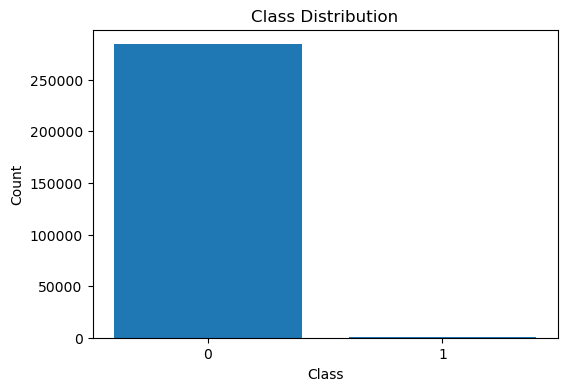

In [12]:
class_counts = df["Class"].value_counts()

plt.figure(figsize=(6,4))

plt.bar(
    class_counts.index.astype(str),
    class_counts.values
)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

# Observation:
# Dataset is highly imbalanced.



#### 6. EDA - TRANSACTION AMOUNT



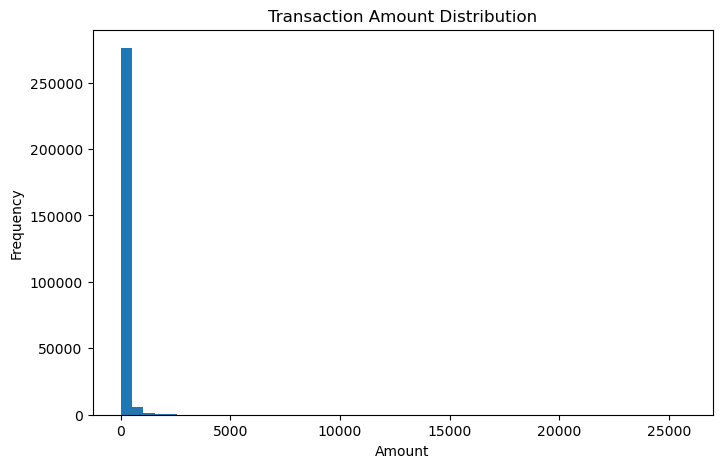

In [13]:

plt.figure(figsize=(8,5))

plt.hist(
    df["Amount"],
    bins=50
)

plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")

plt.show()

# Observation:
# Most transactions are of smaller amounts.



#### 7. FRAUD VS NORMAL AMOUNT



C:\Users\Rehan\AppData\Local\Temp\ipykernel_14488\467470186.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


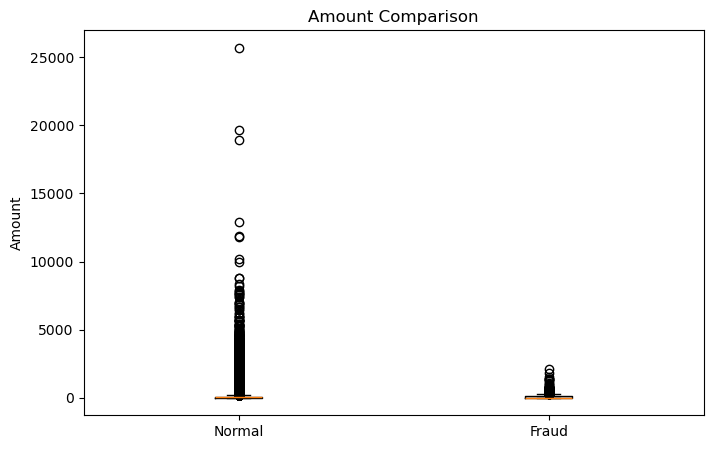

In [ ]:

normal_amounts = df[df["Class"] == 0]["Amount"]
fraud_amounts = df[df["Class"] == 1]["Amount"]

plt.figure(figsize=(8,5))

plt.boxplot(
    [normal_amounts, fraud_amounts],
    labels=["Normal", "Fraud"]
)

plt.ylabel("Amount")
plt.title("Amount Comparison")

plt.show()

# Observation:
# Fraud transactions tend to have different amount patterns than normal trasactions.


#### 8. FEATURE ENGINEERING

In [15]:

# Scale Amount column

amount_scaler = StandardScaler()

df["scaled_amount"] = amount_scaler.fit_transform(
    df[["Amount"]]
)

# Scale Time column

time_scaler = StandardScaler()

df["scaled_time"] = time_scaler.fit_transform(
    df[["Time"]]
)

# Drop original columns

df.drop(
    ["Amount", "Time"],
    axis=1,
    inplace=True
)



#### 9. FEATURE-TARGET SPLIT




In [17]:

X = df.drop("Class", axis=1)
y = df["Class"]



#### 10. TRAIN TEST SPLIT



In [19]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)



Training Shape: (227845, 30)
Testing Shape: (56962, 30)





### 11. BASELINE MODEL
####     LOGISTIC REGRESSION


In [20]:


lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

lr.fit(
    X_train,
    y_train
)

# Predictions

lr_pred = lr.predict(X_test)





### 12. LOGISTIC REGRESSION EVALUATION



In [21]:
print("\nLOGISTIC REGRESSION REPORT")

print(
    classification_report(
        y_test,
        lr_pred
    )
)



LOGISTIC REGRESSION REPORT
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



In [22]:

# ROC-AUC

lr_prob = lr.predict_proba(X_test)[:, 1]

lr_auc = roc_auc_score(
    y_test,
    lr_prob
)


print("ROC AUC Score:", lr_auc)


ROC AUC Score: 0.9721669425367221


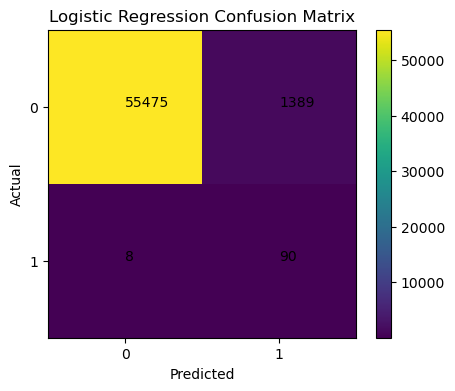

In [23]:

# Confusion Matrix

cm = confusion_matrix(
    y_test,
    lr_pred
)

plt.figure(figsize=(5,4))

plt.imshow(cm)

plt.colorbar()

plt.xticks([0,1])
plt.yticks([0,1])

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j])

plt.title("Logistic Regression Confusion Matrix")

plt.show()




#### 13. RANDOM FOREST MODEL




In [24]:

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(X_test)





#### 14. RANDOM FOREST EVALUATION



In [25]:

print("\nRANDOM FOREST REPORT")

print(
    classification_report(
        y_test,
        rf_pred
    )
)

rf_prob = rf.predict_proba(X_test)[:,1]

rf_auc = roc_auc_score(
    y_test,
    rf_prob
)

print("ROC AUC Score:", rf_auc)



RANDOM FOREST REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.81      0.81      0.81        98

    accuracy                           1.00     56962
   macro avg       0.90      0.90      0.90     56962
weighted avg       1.00      1.00      1.00     56962

ROC AUC Score: 0.9858697945976365


PR AUC: 0.8194035326970106


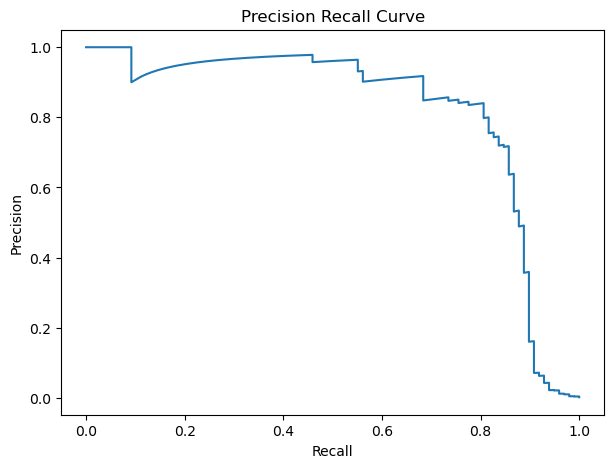

In [26]:

precision, recall, thresholds = precision_recall_curve(
    y_test,
    rf_prob
)

pr_auc = auc(
    recall,
    precision
)

print("PR AUC:", pr_auc)

plt.figure(figsize=(7,5))

plt.plot(
    recall,
    precision
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision Recall Curve")

plt.show()





#### 15. HYPERPARAMETER TUNING


In [27]:


params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 15]
}

grid = GridSearchCV(
    RandomForestClassifier(
        class_weight="balanced",
        random_state=42
    ),
    param_grid=params,
    scoring="f1",
    cv=3,
    n_jobs=-1
)

grid.fit(
    X_train,
    y_train
)

print("\nBest Parameters:")
print(grid.best_params_)

best_rf = grid.best_estimator_



Best Parameters:
{'max_depth': 15, 'n_estimators': 100}




#### 16. FEATURE IMPORTANCE



In [28]:

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 10 Important Features")

print(
    importance.head(10)
)



Top 10 Important Features
   Feature  Importance
13     V14    0.217144
9      V10    0.115331
3       V4    0.103927
16     V17    0.090971
10     V11    0.073989
11     V12    0.072535
2       V3    0.069812
15     V16    0.039989
6       V7    0.033064
1       V2    0.023404


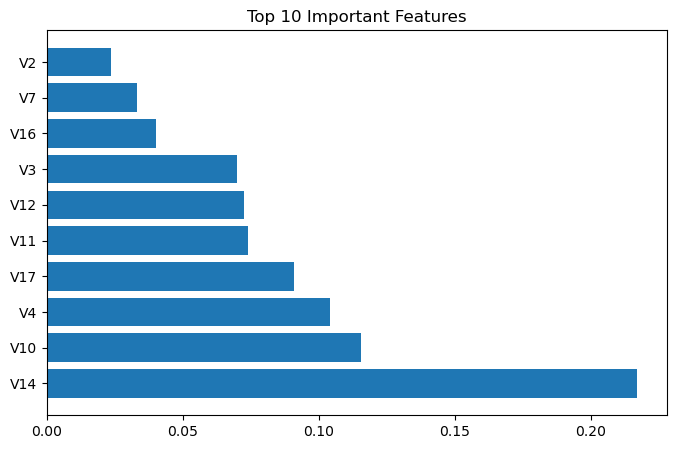

In [29]:

# Plot Top Features

top10 = importance.head(10)

plt.figure(figsize=(8,5))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.title("Top 10 Important Features")

plt.show()




#### 17. FINAL MODEL EVALUATION


In [30]:

final_pred = best_rf.predict(X_test)

print("\nFINAL MODEL REPORT")

print(
    classification_report(
        y_test,
        final_pred
    )
)

final_auc = roc_auc_score(
    y_test,
    best_rf.predict_proba(X_test)[:,1]
)

print("Final ROC AUC:", final_auc)





FINAL MODEL REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.90      0.80      0.84        98

    accuracy                           1.00     56962
   macro avg       0.95      0.90      0.92     56962
weighted avg       1.00      1.00      1.00     56962

Final ROC AUC: 0.9653906599921905


#### 19. MODEL COMPARISON


In [34]:


results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "ROC_AUC": [
        lr_auc,
        final_auc
    ]
})

print("\nModel Comparison")

print(results)



Model Comparison
                 Model   ROC_AUC
0  Logistic Regression  0.972167
1        Random Forest  0.965391
